In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import math
sys.path.append(os.path.abspath("../Paraproducts"))
from tensor_paraproducts import haar_paraproduct
import pickle

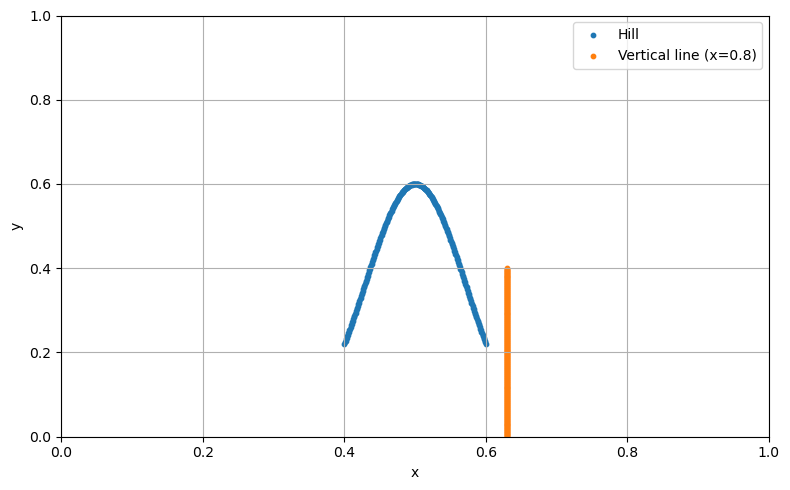

In [2]:
N = 256

# Hill: x evenly spaced in [0.3, 0.5], y is a Gaussian bell curve + small noise
hill_x = np.linspace(0.4, 0.6, N)
hill_y = np.exp(-((hill_x - 0.5) / .1) ** 2) *.6

# Vertical line: all x = 0.8, y evenly spaced 0 to 1
line_x = np.full(N, 0.63)
line_y = np.linspace(0, 0.4, N)

plt.figure(figsize=(8, 5))
plt.scatter(hill_x, hill_y, s=10, label='Hill')
plt.scatter(line_x, line_y, s=10, label='Vertical line (x=0.8)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# Define Parameters
dim = [64,128,256,512]
scales = [4,5,6,7]
xloc = [.61,.71,.81,.91]
deg = 64

In [4]:
# Run experiments

# Initially dictionary for storage
datadict = {}

for N in dim:
    for mxscl in scales:
        for k in xloc:

            if mxscl > int(np.log2(N)):
                continue
            
            # Generate coordinates
            hill_x = np.linspace(0.4, 0.6, N)
            hill_y = np.exp(-((hill_x - 0.5) / .1) ** 2) *.6
            
            line_x = np.full(N, k)
            line_y = np.linspace(0, 0.4, N)
            
            hill_x = np.expand_dims(hill_x,axis=1)
            hill_y = np.expand_dims(hill_y,axis=1)
            line_x = np.expand_dims(line_x,axis=1)
            line_y = np.expand_dims(line_y,axis=1)
            hill = np.concatenate((hill_x,hill_y),axis=1)
            line = np.concatenate((line_x,line_y),axis=1)
            datadict['coords'] = [(hill,line)] 
            
            # Compute distance matrix
            dxy = np.zeros((N,N))
            for i in range(N):
                for j in range(N):
                    dxy[i,j] = np.linalg.norm(hill[i] - line[j])
            datadict['dxy'] = dxy

            # Compute coefficient matrices
            deg = 25
            coefmat_deg = np.zeros((N,N))
            coefmat_zro = np.zeros((N,N))
            x = np.linspace(0, 2*np.pi, N)
            y = np.linspace(0, 2*np.pi, N)
            for j in range(len(x)):
                for i in range(len(y)):
                    coefmat_deg[i,j] = np.sin((1/( (deg + 1) +2))*x[j]) + np.cos((1/( (deg + 1) +2))*y[i])
                    coefmat_zro[i,j] = np.sin(0.5*x[j]) + np.cos(0.5*y[i])

            # Compute kernel
            eps = (1/dxy)-1
            poly = ((coefmat_deg*(dxy**(-(deg + 1)))) - coefmat_zro)*(eps**(-1))
            Af = np.log(poly + 1e-10)        
            datadict['Af'] = Af

            # Initialize class, set parameters
            hp = haar_paraproduct(dxy,Af)
            Nj=Njp=6 # Fixed scales for wavelet computations

            # Define Parameters
            hp.deg = deg
            hp.coeffn = coefmat_deg
            hp.coeffzro = coefmat_zro
            hp.eps = eps
            hp.kernel = 'log'
            hp.alf=0.25

            # Compute distance coefficients
            _, dxycoeffs, _ = hp.twave_approx(dxy,Nj,Njp)
            datadict['dxycoeffs'] = dxycoeffs
            
            # Compute Paraproduct Decomposition
            Afpara = hp.para_approx(mxscl,mxscl)

            # Normalization
            paranorm = Afpara/np.max(np.abs(Afpara))
            Afnorm = Af/np.max(np.abs(Af))

            # Compute Holder norm
            _, _, paramet = hp.twave_approx(paranorm,Nj,Njp)
            _, _, Afmet = hp.twave_approx(Afnorm,Nj,Njp)
            relvar = (np.sum(paramet)/np.sum(Afmet))

            # Save Metrics/Data
            datadict['Afnorm'] = Afnorm
            datadict['paranorm'] = paranorm
            datadict['logvar'] = relvar
            
            # Save dictionary
            with open(f"Logpot_XP_deg64_vcoef_3_10/{N}_{mxscl}_{k}.pkl", "wb") as q:
                pickle.dump(datadict, q)


# Save Data, Distance matrix, Haar coefficients of distance matrix, nonlinear transformation
# Save wavelet and paraproduct approxs, Relative Condition Numbers between paraproduct/tensor haar

In [5]:
with open(f"Logpot_XP/{N}_{mxscl}_{deg}.pkl", 'rb') as file:
    data = pickle.load(file)


plt.figure()
coefs = np.array(data['dxycoeffs'])
plt.plot(np.log2(coefs))

plt.figure()
plt.imshow(data['Af'])

plt.figure()
plt.imshow(data['waveapprox'])

plt.figure()
plt.imshow(data['parapprox'])

print(rcond)

FileNotFoundError: [Errno 2] No such file or directory: 'Logpot_XP/512_7_25.pkl'

In [5]:
print(N)

128


In [ ]:
print(deg)